# Smooth Curve JSON Editor

Edit smooth curves in JSON GAM model files (`curves.simple` and `curves.interactions[*].variants`).

The N-drive model is treated as a read-only source. On first run the notebook copies it into `smooth/local_models/` (gitignored). Edits write new files alongside the local baseline; existing outputs are never overwritten. Reusable helpers live in [`smooth_utils.py`](smooth_utils.py).

In [53]:
from __future__ import annotations

import copy
import importlib
from pathlib import Path

import matplotlib.pyplot as plt
import smooth_utils

importlib.reload(smooth_utils)

from smooth_utils import (
    curve_to_df,
    edited_output_path,
    ensure_local_model_copy,
    extract_control_points,
    find_curve,
    list_curves,
    plot_curve,
    plot_model_curves,
    read_model_json,
    rebuild_curve,
    update_curve,
    write_model_json,
)

SOURCE_MODEL_PATH = Path(
    r"C:\Git\LMSimData\data\JUMBO2\ModelFiles\1.8.1\original\jumbo_refinance_1.5.update_2026_02_10_10_36_41.946555.json"
)
LOCAL_MODELS_DIR = Path(r"s:\QR\hzeng\howard-toolbox\smooth\local_models")
LOCAL_MODEL_PATH = LOCAL_MODELS_DIR / SOURCE_MODEL_PATH.name
OUTPUT_PATH = edited_output_path(LOCAL_MODEL_PATH)

ensure_local_model_copy(SOURCE_MODEL_PATH, LOCAL_MODEL_PATH)
LOCAL_MODEL_PATH

Using existing local baseline copy: s:\QR\hzeng\howard-toolbox\smooth\local_models\jumbo_refinance_1.5.update_2026_02_10_10_36_41.946555.json


WindowsPath('s:/QR/hzeng/howard-toolbox/smooth/local_models/jumbo_refinance_1.5.update_2026_02_10_10_36_41.946555.json')

In [54]:
model = read_model_json(LOCAL_MODEL_PATH)
list_curves(model)

,group,name,selector_field,selector_value,n_points,x_min,x_max,y_min,y_max
0,simple,burnout_spread_llpa_lag0,None,None,100,0.00,1.600000e+02,-1.287149,0.169021
1,simple,factor,None,None,100,0.10,1.000000e+00,-2.029484,0.069386
2,simple,hpa_lag2_itd,None,None,100,1.40,2.500000e+00,-0.006951,0.386510
3,simple,orig_amt_infladj_2025,None,None,100,100000.00,2.000000e+06,-1.177938,0.159644
4,simple,orig_fico,None,None,100,675.00,8.000000e+02,-0.543327,0.171222
5,simple,sato_lag0_llpa,None,None,100,-0.75,7.500000e-01,-0.432987,0.463231
6,simple,upd_cltv,None,None,100,15.00,1.100000e+02,-1.740148,0.142563
7,interaction,age_noterate,noterate_bucket,low,100,0.00,1.600000e+01,-2.850225,0.264723
8,interaction,age_noterate,noterate_bucket,high,100,0.00,1.600000e+01,-0.598317,0.145033
9,interaction,inc_0_spread_llpa_noterate_occ,noterate_occ,low,100,-0.10,2.000000e+00,-2.557066,2.335378


In [55]:
# Optional: narrow the curve list before picking one to edit.
list_curves(model, contains="media")

,group,name,selector_field,selector_value,n_points,x_min,x_max,y_min,y_max
0,interaction,media_6m1m_spread_noterate,noterate_bucket,low,100,-0.05,0.6,-0.645133,0.342409
1,interaction,media_6m1m_spread_noterate,noterate_bucket,high,200,-0.05,0.6,-0.587989,0.473815


In [67]:
df_original[df_original["x"] >= 0.09]

,x,y
43,0.090452,0.017273
44,0.093719,0.033582
45,0.096985,0.050022
46,0.100251,0.066558
47,0.103518,0.083154
...,...,...
195,0.586935,0.409520
196,0.590201,0.407187
197,0.593467,0.404823
198,0.596734,0.402427


Original controls:
(-0.05, -0.587988793294)
(0.0708542713568, -0.0758023165181)
(0.145979899497, 0.287994723765)
(0.168844221106, 0.372303273487)
(0.188442211055, 0.417945075463)
(0.19824120603, 0.428963915479)
(0.21783919598, 0.438385720747)
(0.283165829146, 0.459831209803)
(0.345226130653, 0.469538368384)
(0.430150753769, 0.473607792843)
(0.469346733668, 0.467756758862)
(0.511809045226, 0.453121223766)
(0.554271356784, 0.430965411033)
(0.6, 0.4)

New controls:
(0.100251, 0.066558)
(0.145979899497, 0.287994723765)
(0.168844221106, 0.372303273487)
(0.188442211055, 0.417945075463)
(0.19824120603, 0.428963915479)
(0.21783919598, 0.438385720747)
(0.283165829146, 0.459831209803)
(0.345226130653, 0.469538368384)
(0.430150753769, 0.473607792843)
(0.469346733668, 0.467756758862)
(0.511809045226, 0.453121223766)
(0.554271356784, 0.430965411033)
(0.6, 0.4)


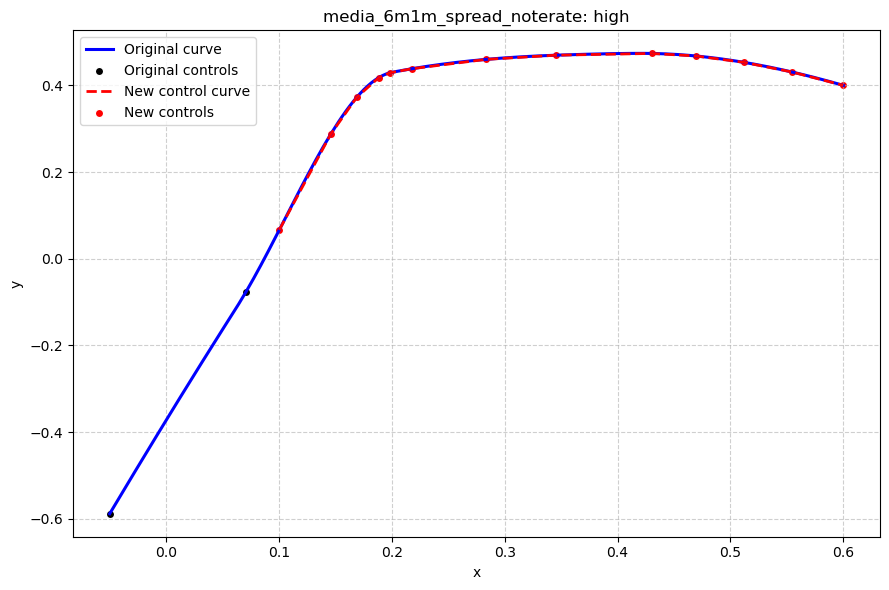

In [69]:
CURVE_NAME = "media_6m1m_spread_noterate"
SELECTOR_VALUE = "high"  # Use None for curves under curves.simple.

curve = find_curve(model, name=CURVE_NAME, selector_value=SELECTOR_VALUE)
df_original = curve_to_df(curve)

original_controls = extract_control_points(
    df_original["x"],
    df_original["y"],
    tolerance=0.0025,
)

new_controls = [
    (0.100251, 0.066558),
    (0.145979899497, 0.287994723765),
    (0.168844221106, 0.372303273487),
    (0.188442211055, 0.417945075463),
    (0.19824120603, 0.428963915479),
    (0.21783919598, 0.438385720747),
    (0.283165829146, 0.459831209803),
    (0.345226130653, 0.469538368384),
    (0.430150753769, 0.473607792843),
    (0.469346733668, 0.467756758862),
    (0.511809045226, 0.453121223766),
    (0.554271356784, 0.430965411033),
    (0.6, 0.4)
]

# The rebuild cell below uses `controls`, so choose which curve to apply here.
controls = new_controls

print("Original controls:")
for point in original_controls:
    print(point)

print("\nNew controls:")
for point in new_controls:
    print(point)

plt.figure(figsize=(9, 6))
plt.plot(df_original["x"], df_original["y"], color="blue", linewidth=2.2, label="Original curve")
plt.scatter(*zip(*original_controls), c="black", edgecolor="white", label="Original controls")
plt.plot(*zip(*new_controls), "--", color="red", linewidth=2, label="New control curve")
plt.scatter(*zip(*new_controls), c="red", edgecolor="white", label="New controls")
plt.title(f"{CURVE_NAME}: {SELECTOR_VALUE}")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

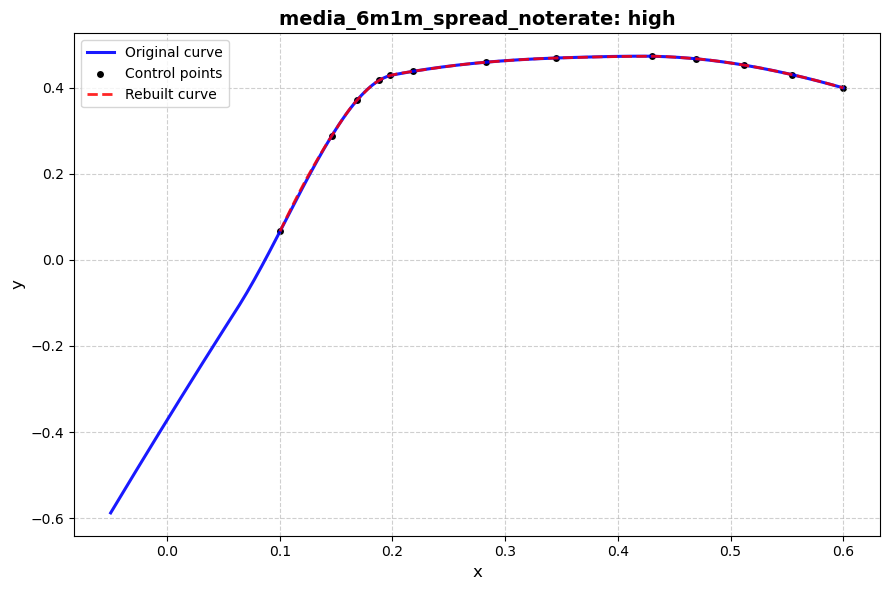

,x,y
0,0.100251,0.066558
1,0.102762,0.080539
2,0.105274,0.094296
3,0.107785,0.107831
4,0.110296,0.121147


In [71]:
# Edit `control_points` to reshape the curve, then rerun this cell.
control_points = controls

# Example: define a custom shape from scratch.
# control_points = [
#     (df_original["x"].min(), df_original["y"].iloc[0]),
#     (0.0, -0.05),
#     (0.3, 0.10),
#     (df_original["x"].max(), df_original["y"].iloc[-1]),
# ]

N_POINTS = int(curve.get("n_points", len(df_original)))
METHOD = "pchip"

df_curve = rebuild_curve(
    controls=control_points,
    x_original=df_original["x"],
    y_original=df_original["y"],
    n_points=N_POINTS,
    method=METHOD,
    title=f"{CURVE_NAME}: {SELECTOR_VALUE}",
)

df_curve.head()

In [72]:
model_edit = copy.deepcopy(model)
updated_curve = update_curve(
    model_edit,
    name=CURVE_NAME,
    selector_value=SELECTOR_VALUE,
    df_curve=df_curve,
)

print(f"Updated {CURVE_NAME} / {SELECTOR_VALUE}")
print(f"n_points: {updated_curve['n_points']}")
print(f"x range: {updated_curve['x_min']} to {updated_curve['x_max']}")

# Write a fresh edited JSON copy so you can review the change.
# Each rerun creates a new file: foo.smooth_edit.json, foo.smooth_edit_001.json, ...
written_path = write_model_json(model_edit, OUTPUT_PATH)
print(f"Wrote edited model to: {written_path}")

Updated media_6m1m_spread_noterate / high
n_points: 200
x range: 0.100251 to 0.6
Wrote edited model to: s:\QR\hzeng\howard-toolbox\smooth\local_models\jumbo_refinance_1.5.update_2026_02_10_10_36_41.946555.smooth_edit_001.json


## Plot Smooth Curves

Load an edited model JSON and plot all simple smooths plus interaction smooths. Interaction variants are overlaid by selector value.

In [ ]:
EDITED_MODEL_PATH = LOCAL_MODELS_DIR / "jumbo_refinance_1.5.update_2026_02_10_10_36_41.946555.smooth_edit.json"
edited_model = read_model_json(EDITED_MODEL_PATH)

plot_model_curves(edited_model)

# Examples for focused plots:
# plot_model_curves(edited_model, contains="media")
# plot_curve(edited_model, name="sato_lag0_llpa")